# Accumulation / Distribution Feature Lab

10 new features tracking buying vs selling pressure. None exist in ProcessedData.

1. `acc_cmf_20` Chaikin Money Flow
2. `acc_up_vol_ratio_20` fraction of volume on up days
3. `acc_adl_slope_14` A/D Line slope (z-scored)
4. `acc_pvt_slope_20` Price-Volume Trend slope
5. `acc_dist_balance_20` high-vol up days vs high-vol down days
6. `acc_vol_efficiency` Wyckoff effort-vs-result (z-scored)
7. `acc_confirm_rate_10` price+volume confirmation rate
8. `acc_hvol_up_pct_30` pct of heavy sessions that were up
9. `acc_obv_slope_20` OBV slope (z-scored)
10. `acc_bull_composite` rank-blend of signals 1+2+5+9


In [1]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
from tqdm import tqdm
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
DATA_DIR = 'Data/ProcessedData'
TARGET_COL = 'percent_change_Close'
N_SAMPLE = 150
MIN_ROWS = 200
RANDOM_SEED = 42
ACC_FEATURES = [
    'acc_cmf_20', 'acc_up_vol_ratio_20', 'acc_adl_slope_14',
    'acc_pvt_slope_20', 'acc_dist_balance_20', 'acc_vol_efficiency',
    'acc_confirm_rate_10', 'acc_hvol_up_pct_30', 'acc_obv_slope_20', 'acc_bull_composite',
]
np.random.seed(RANDOM_SEED)
print('Setup complete.')


Setup complete.


## 1. Feature Engineering


In [2]:
def compute_accumulation_features(df):
    df = df.copy()
    close = df['Close'].astype(float)
    high = df['High'].astype(float)
    low = df['Low'].astype(float)
    volume = df['Volume'].astype(float).clip(lower=1)
    hl_range = (high - low).clip(lower=1e-8)
    clv = ((close - low) - (high - close)) / hl_range
    mf_vol = clv * volume
    vol_ma = volume.rolling(20, min_periods=5).mean().clip(lower=1)

    # 1. Chaikin Money Flow (20d) -- CLV*vol rolling sum / vol rolling sum
    df['acc_cmf_20'] = (
        mf_vol.rolling(20, min_periods=10).sum() /
        volume.rolling(20, min_periods=10).sum()
    )

    # 2. Up-Volume Ratio -- fraction of total volume that came on up days
    up_day = (close > close.shift(1)).astype(float)
    df['acc_up_vol_ratio_20'] = (
        (volume * up_day).rolling(20, min_periods=10).sum() /
        volume.rolling(20, min_periods=10).sum()
    )

    # 3. ADL Slope (14d, z-scored)
    adl = mf_vol.cumsum()
    adl_slope = adl.diff(14)
    df['acc_adl_slope_14'] = adl_slope / adl_slope.rolling(50, min_periods=14).std().clip(lower=1e-8)

    # 4. Price-Volume Trend slope (20d)
    pvt = (close.pct_change() * volume).cumsum()
    df['acc_pvt_slope_20'] = pvt.diff(20) / vol_ma

    # 5. Accumulation vs Distribution Balance
    # +1 = all high-vol days up, -1 = all high-vol days down
    vol_above = (volume > vol_ma).astype(float)
    price_up = (close > close.shift(1)).astype(float)
    acc_sum = (vol_above * price_up).rolling(20, min_periods=5).sum()
    dist_sum = (vol_above * (1 - price_up)).rolling(20, min_periods=5).sum()
    df['acc_dist_balance_20'] = (acc_sum - dist_sum) / (acc_sum + dist_sum).clip(lower=1)

    # 6. Volume Efficiency (Wyckoff effort-vs-result, z-scored)
    # Low = high vol but tiny range = absorption zone
    raw_eff = (hl_range / close.clip(lower=0.01)) / (volume / vol_ma).clip(lower=0.01)
    df['acc_vol_efficiency'] = (
        (raw_eff - raw_eff.rolling(50, min_periods=10).mean()) /
        raw_eff.rolling(50, min_periods=10).std().clip(lower=1e-8)
    )

    # 7. Price-Volume Confirmation Rate (10d)
    confirmed = (
        (np.sign(close.diff()) == np.sign(volume.diff())) &
        (np.sign(close.diff()) != 0)
    ).astype(float)
    df['acc_confirm_rate_10'] = confirmed.rolling(10, min_periods=5).mean()

    # 8. High-Volume Up-Day Dominance (30d)
    hvol_total = vol_above.rolling(30, min_periods=10).sum().clip(lower=1)
    df['acc_hvol_up_pct_30'] = (
        (vol_above * price_up).rolling(30, min_periods=10).sum() / hvol_total
    )

    # 9. OBV Slope (20d, z-scored)
    obv_sign = np.where(close > close.shift(1), 1,
               np.where(close < close.shift(1), -1, 0))
    obv = pd.Series((obv_sign * volume.values).cumsum(), index=close.index)
    obv_slope = obv.diff(20)
    df['acc_obv_slope_20'] = obv_slope / obv_slope.rolling(50, min_periods=14).std().clip(lower=1e-8)

    # 10. Bullish Composite -- rolling percentile rank blend
    def rnk(s):
        return s.rolling(120, min_periods=20).rank(pct=True)
    df['acc_bull_composite'] = (
        rnk(df['acc_cmf_20']) + rnk(df['acc_up_vol_ratio_20']) +
        rnk(df['acc_dist_balance_20']) + rnk(df['acc_obv_slope_20'])
    ) / 4.0

    return df

print('Feature functions defined.')


Feature functions defined.


## 2. Load Data


In [3]:
all_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.parquet')])
sample_files = np.random.choice(all_files, size=min(N_SAMPLE, len(all_files)), replace=False)
print(f'Total: {len(all_files)} | Sampling: {len(sample_files)}')

ticker_dfs = {}; skipped = 0
required = ['Open', 'High', 'Low', 'Close', 'Volume', TARGET_COL]

for fname in tqdm(sample_files, desc='Loading'):
    try:
        df = pd.read_parquet(os.path.join(DATA_DIR, fname))
        if len(df) < MIN_ROWS or not all(c in df.columns for c in required):
            skipped += 1; continue
        df = compute_accumulation_features(df)
        df['next_return'] = df[TARGET_COL].shift(-1)
        df['next_up'] = (df['next_return'] > 0).astype(float)
        ticker_dfs[fname.replace('.parquet', '')] = df
    except Exception:
        skipped += 1

print(f'Loaded: {len(ticker_dfs)}  Skipped: {skipped}')


Total: 4265 | Sampling: 150


Loading: 100%|██████████| 150/150 [00:03<00:00, 47.77it/s]

Loaded: 150  Skipped: 0


In [4]:
combined = pd.concat(ticker_dfs.values(), ignore_index=True).replace([np.inf, -np.inf], np.nan)
print(f'Combined: {combined.shape}')
for f in ACC_FEATURES:
    if f in combined.columns:
        print(f'  {f:<32s}  {combined[f].notna().mean()*100:.1f}%')


Combined: (64974, 260)
  acc_cmf_20                        97.9%
  acc_up_vol_ratio_20               97.9%
  acc_adl_slope_14                  93.8%
  acc_pvt_slope_20                  95.2%
  acc_dist_balance_20               99.1%
  acc_vol_efficiency                97.0%
  acc_confirm_rate_10               99.1%
  acc_hvol_up_pct_30                97.9%
  acc_obv_slope_20                  92.4%
  acc_bull_composite                88.0%


## 3. Visualise on Sample Stocks


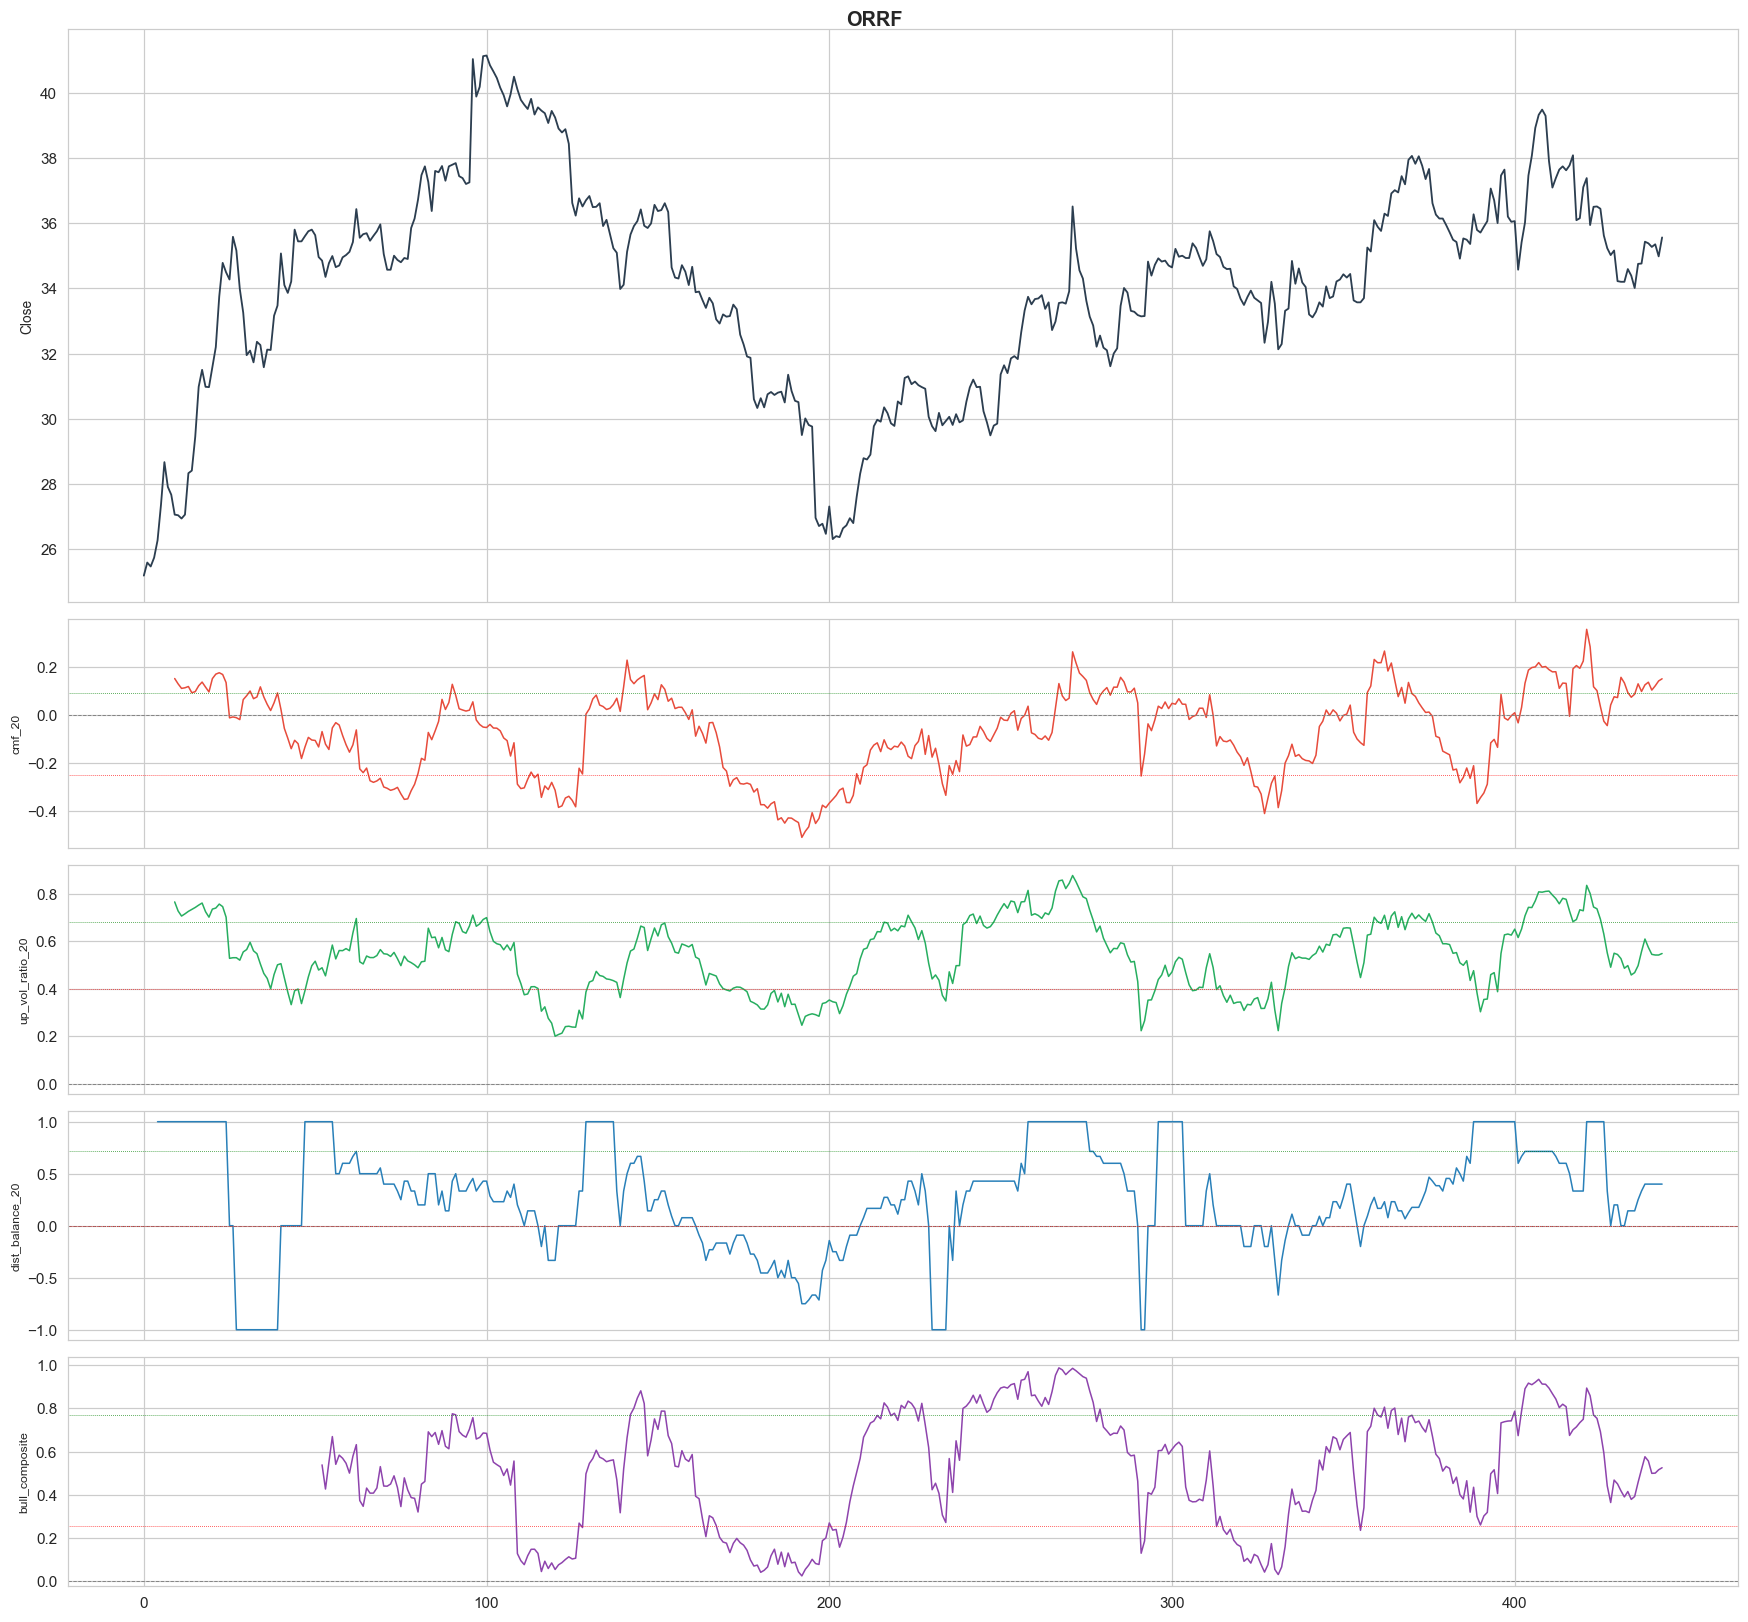

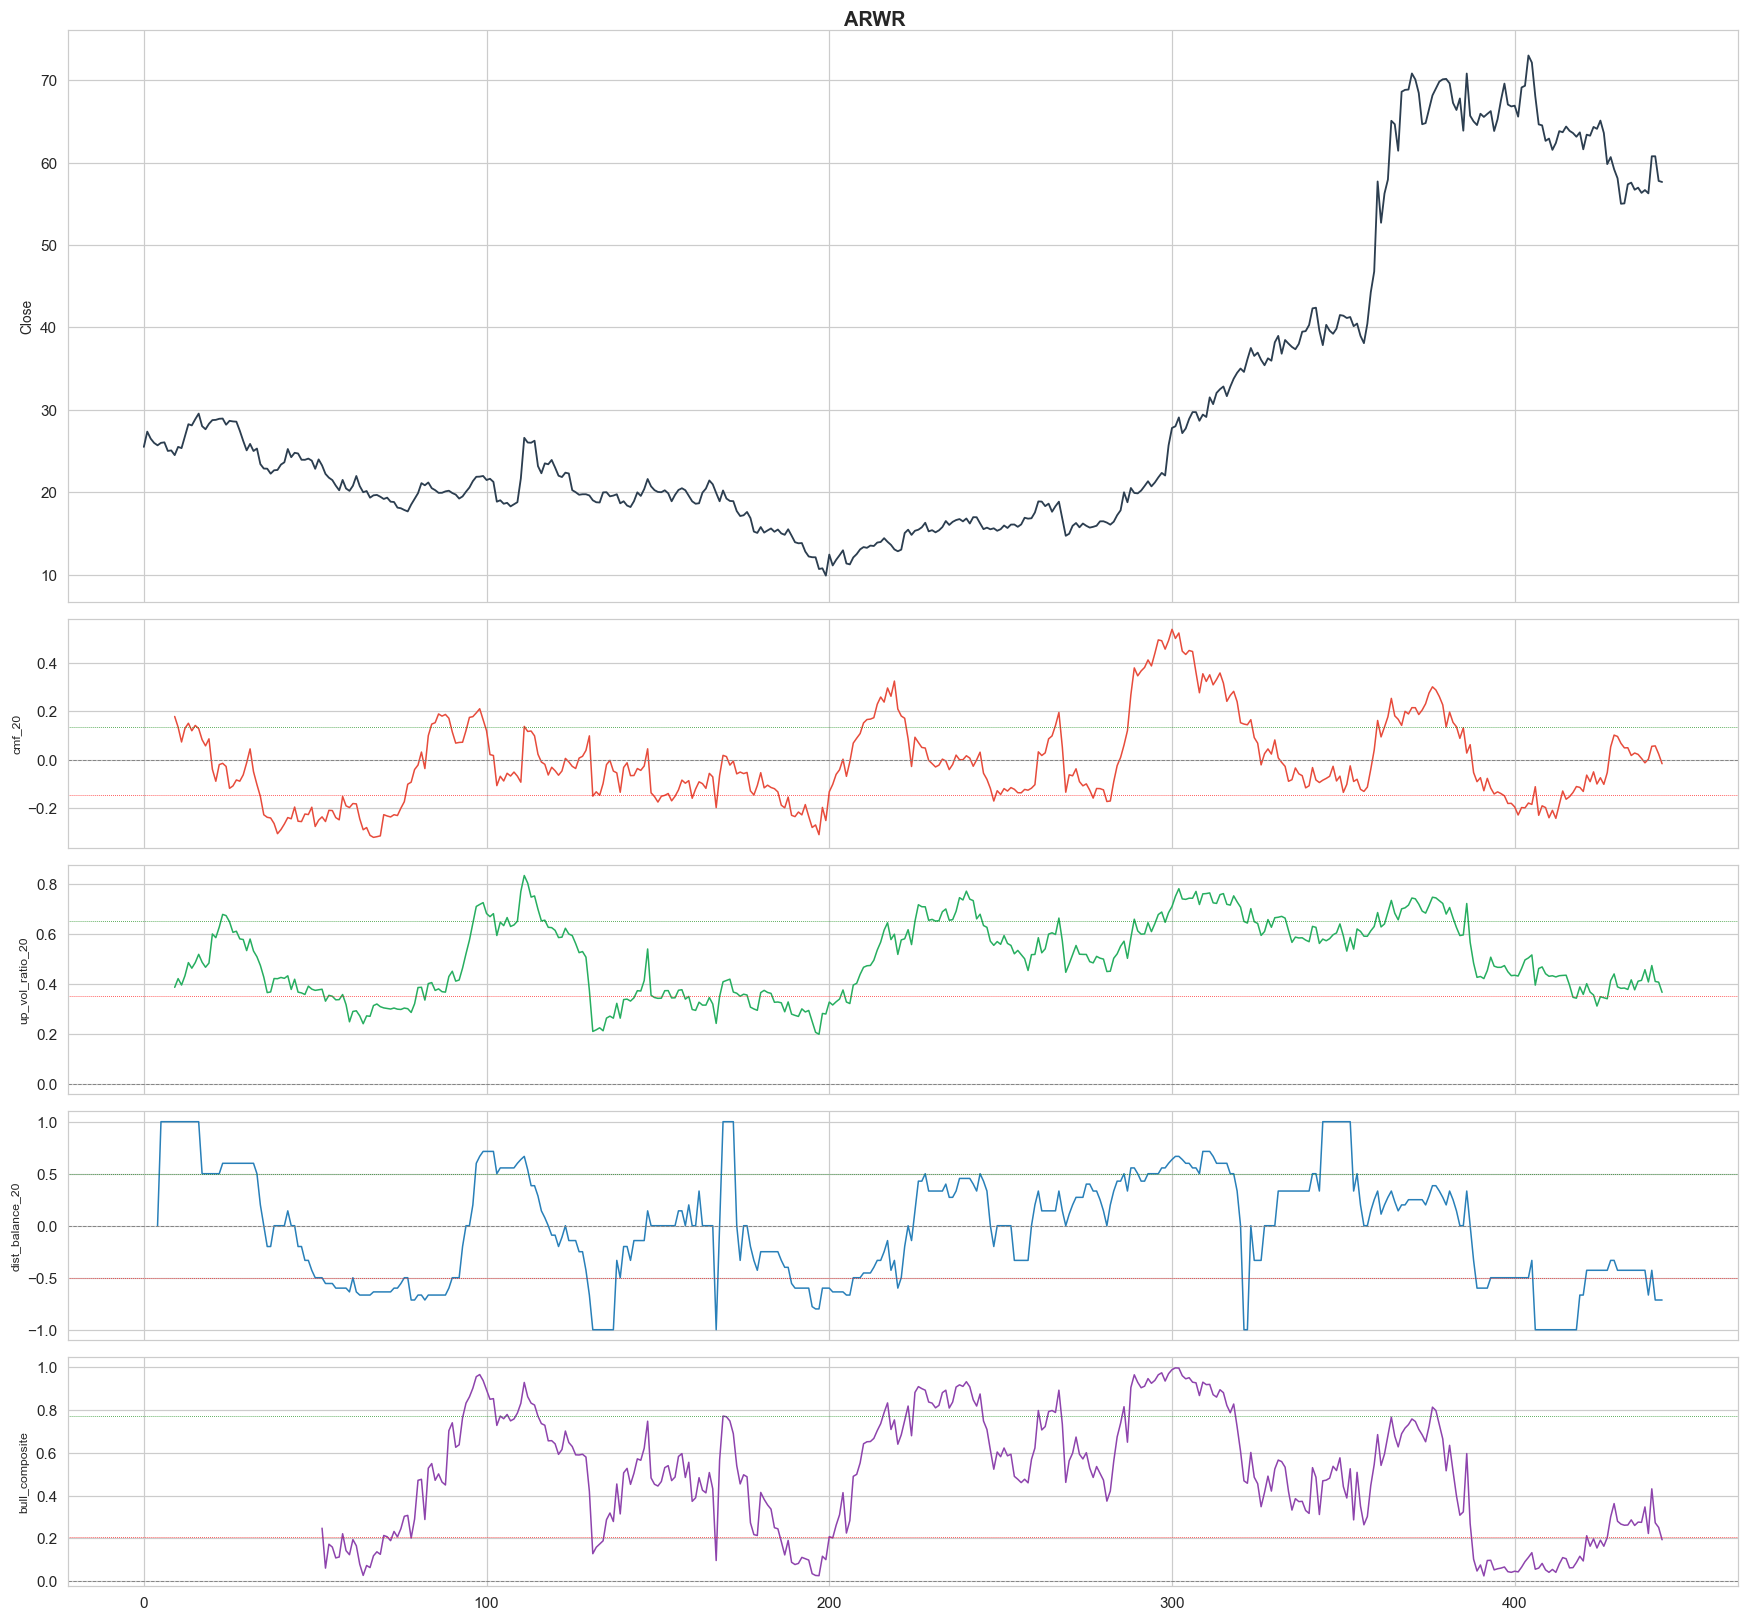

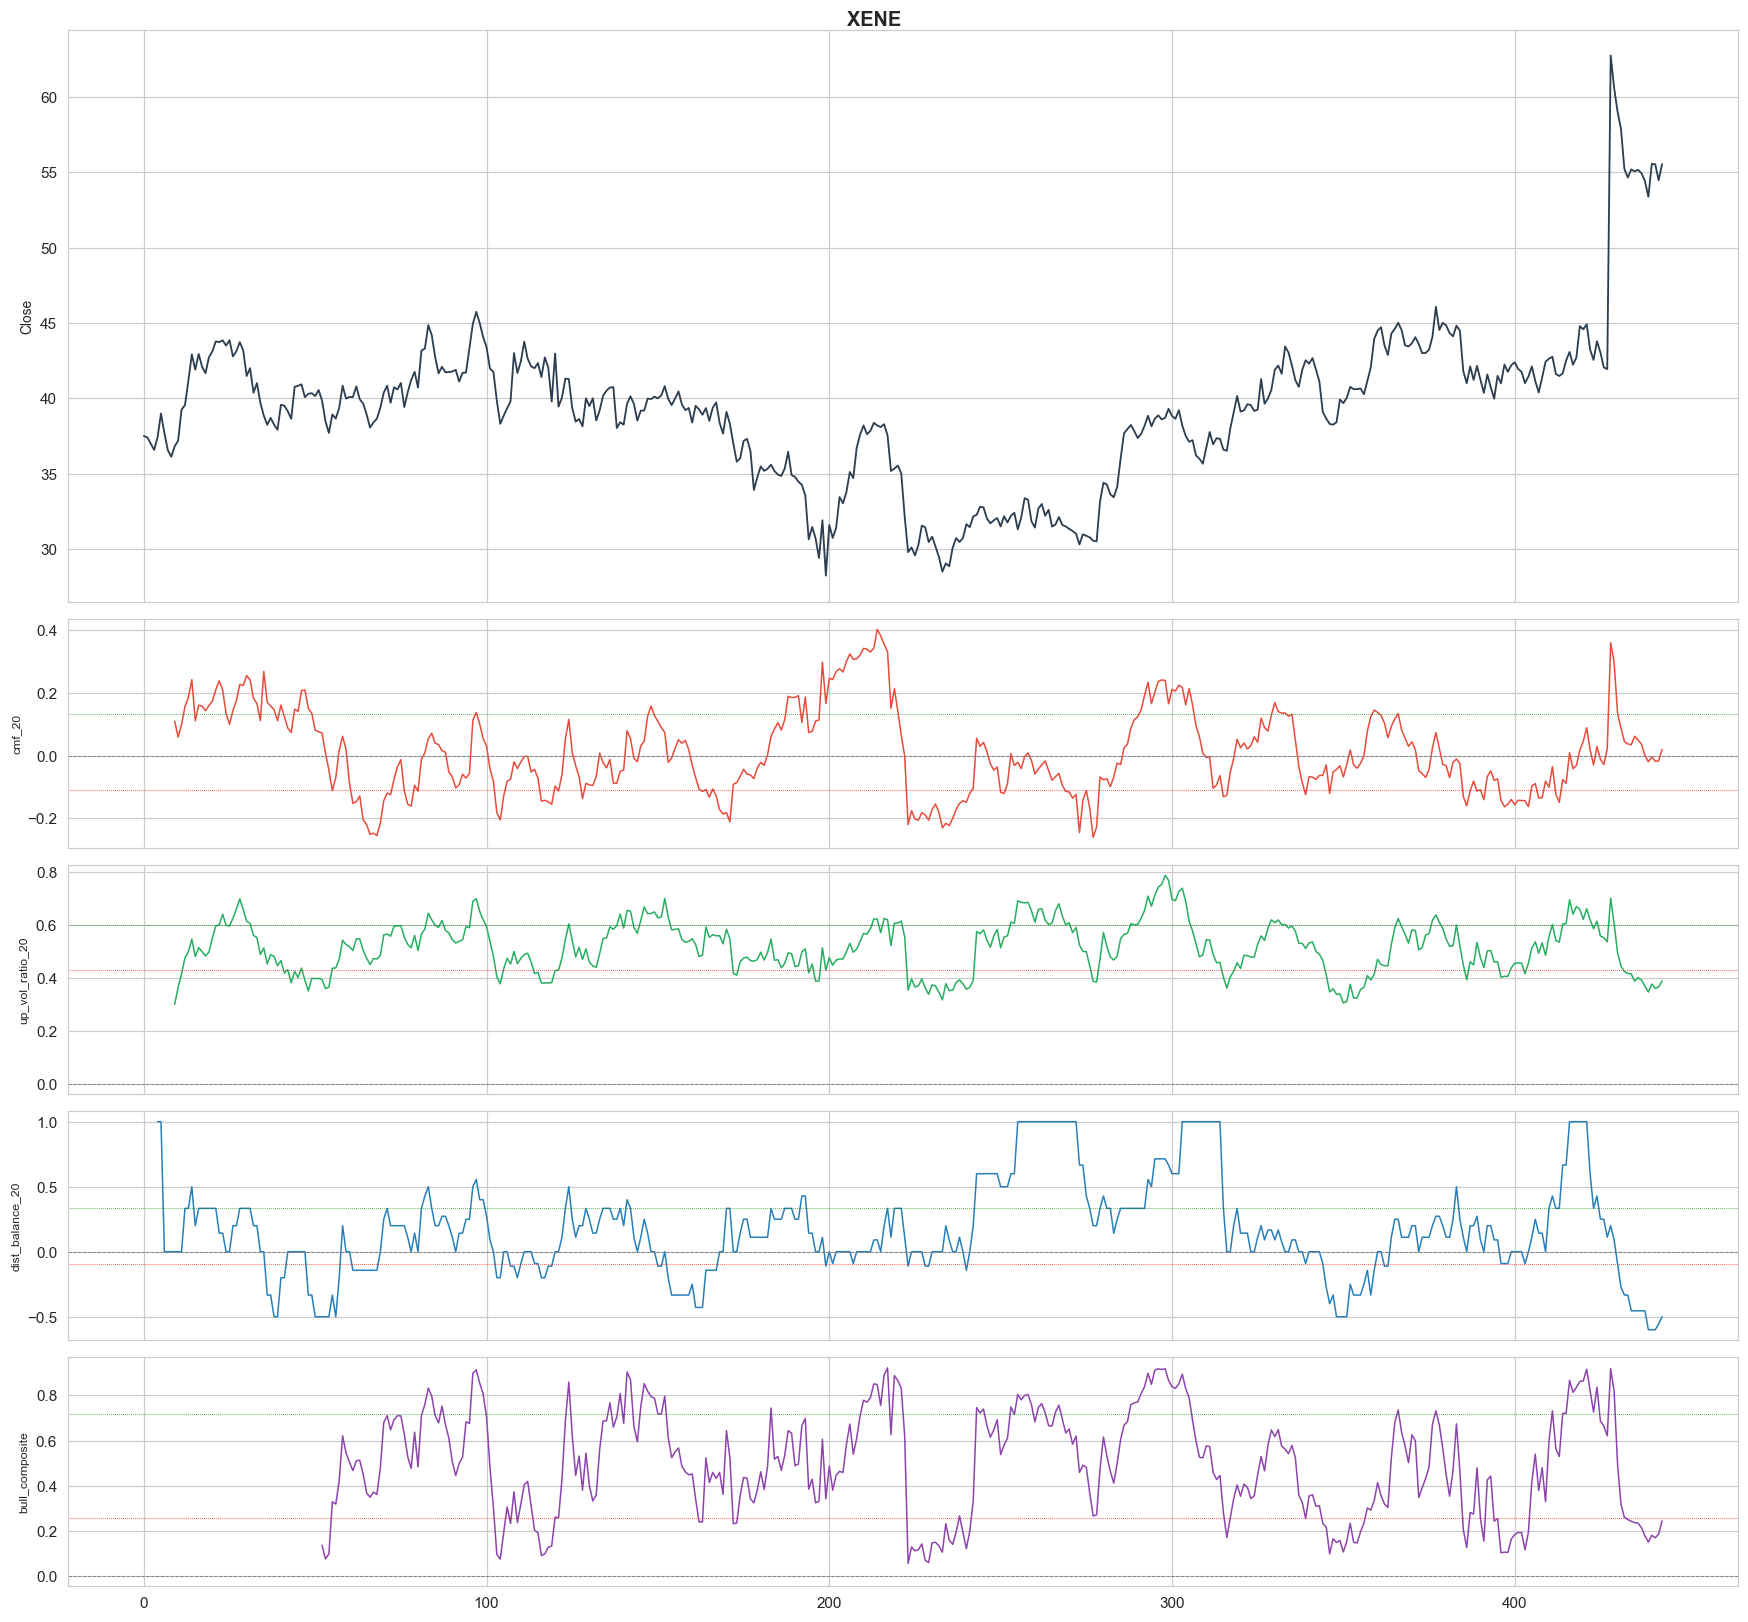

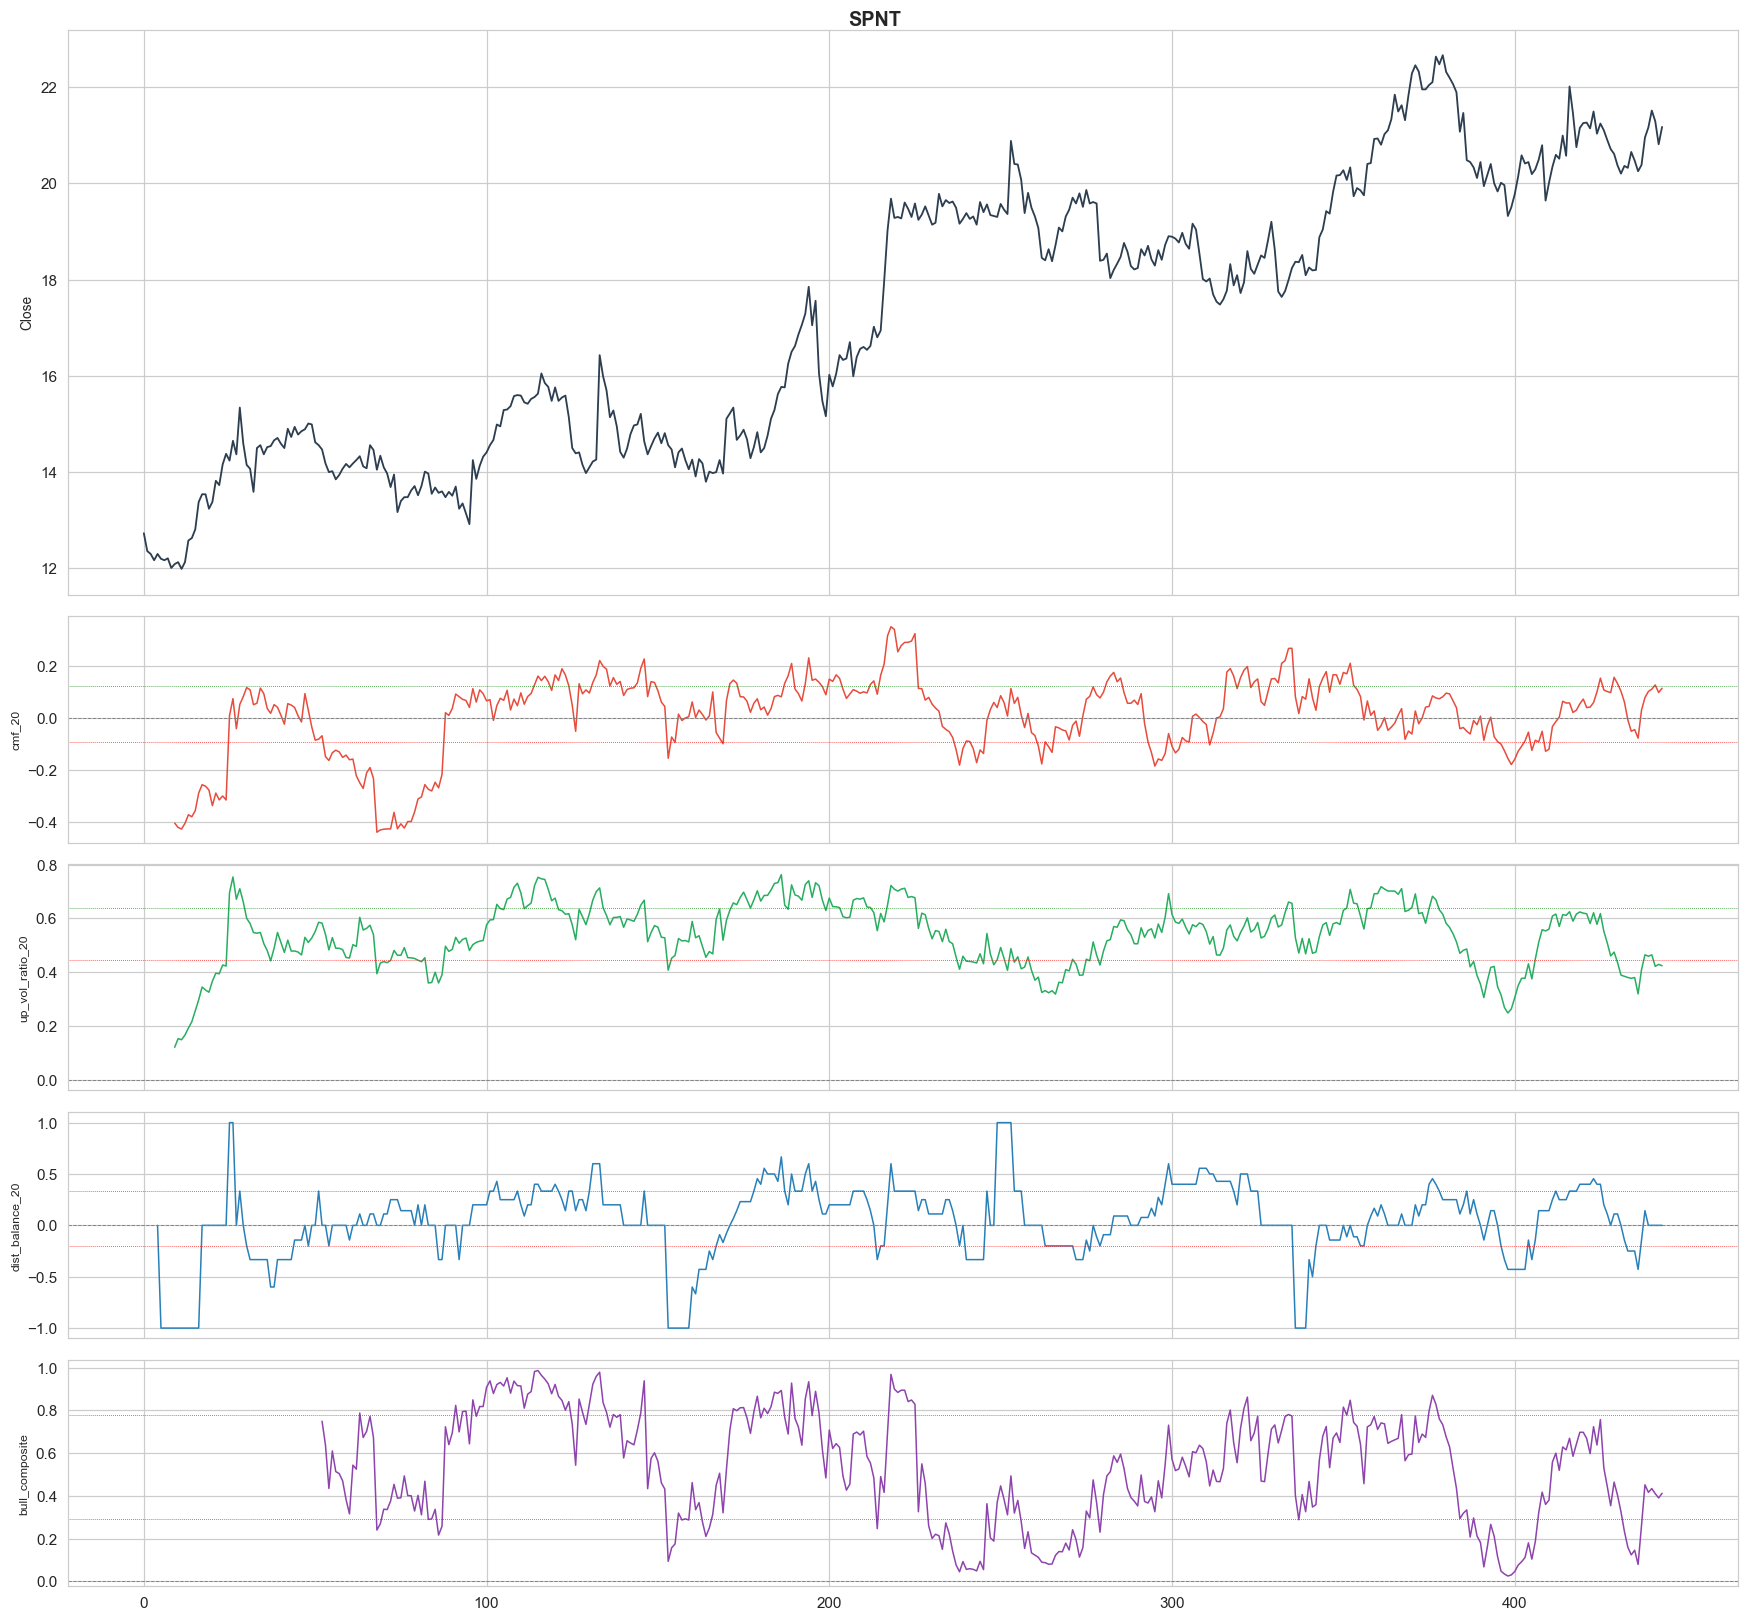

In [5]:
def plot_acc(ticker, df, feats):
    n = 1 + len(feats)
    fig, axes = plt.subplots(n, 1, figsize=(16, 3*n), sharex=True,
                             gridspec_kw={'height_ratios': [2.5]+[1]*len(feats)})
    if n == 1: axes = [axes]
    fig.suptitle(ticker, fontsize=13, fontweight='bold')
    axes[0].plot(df.index, df['Close'], lw=1.2, color='#2c3e50')
    axes[0].set_ylabel('Close', fontsize=9)
    cols = ['#e74c3c', '#27ae60', '#2980b9', '#8e44ad', '#e67e22', '#16a085']
    for i, feat in enumerate(feats):
        ax = axes[i+1]
        if feat not in df.columns: continue
        s = df[feat].dropna()
        ax.plot(s.index, s.values, lw=1.0, color=cols[i % len(cols)])
        ax.axhline(0, lw=0.6, color='grey', ls='--')
        ax.axhline(s.quantile(0.2), lw=0.5, color='red', ls=':')
        ax.axhline(s.quantile(0.8), lw=0.5, color='green', ls=':')
        ax.set_ylabel(feat.replace('acc_', ''), fontsize=8)
    plt.tight_layout(); plt.show()

vis = sorted(ticker_dfs, key=lambda t: len(ticker_dfs[t]), reverse=True)[:4]
flow = ['acc_cmf_20', 'acc_up_vol_ratio_20', 'acc_dist_balance_20', 'acc_bull_composite']
for t in vis:
    plot_acc(t, ticker_dfs[t].reset_index(drop=True), flow)


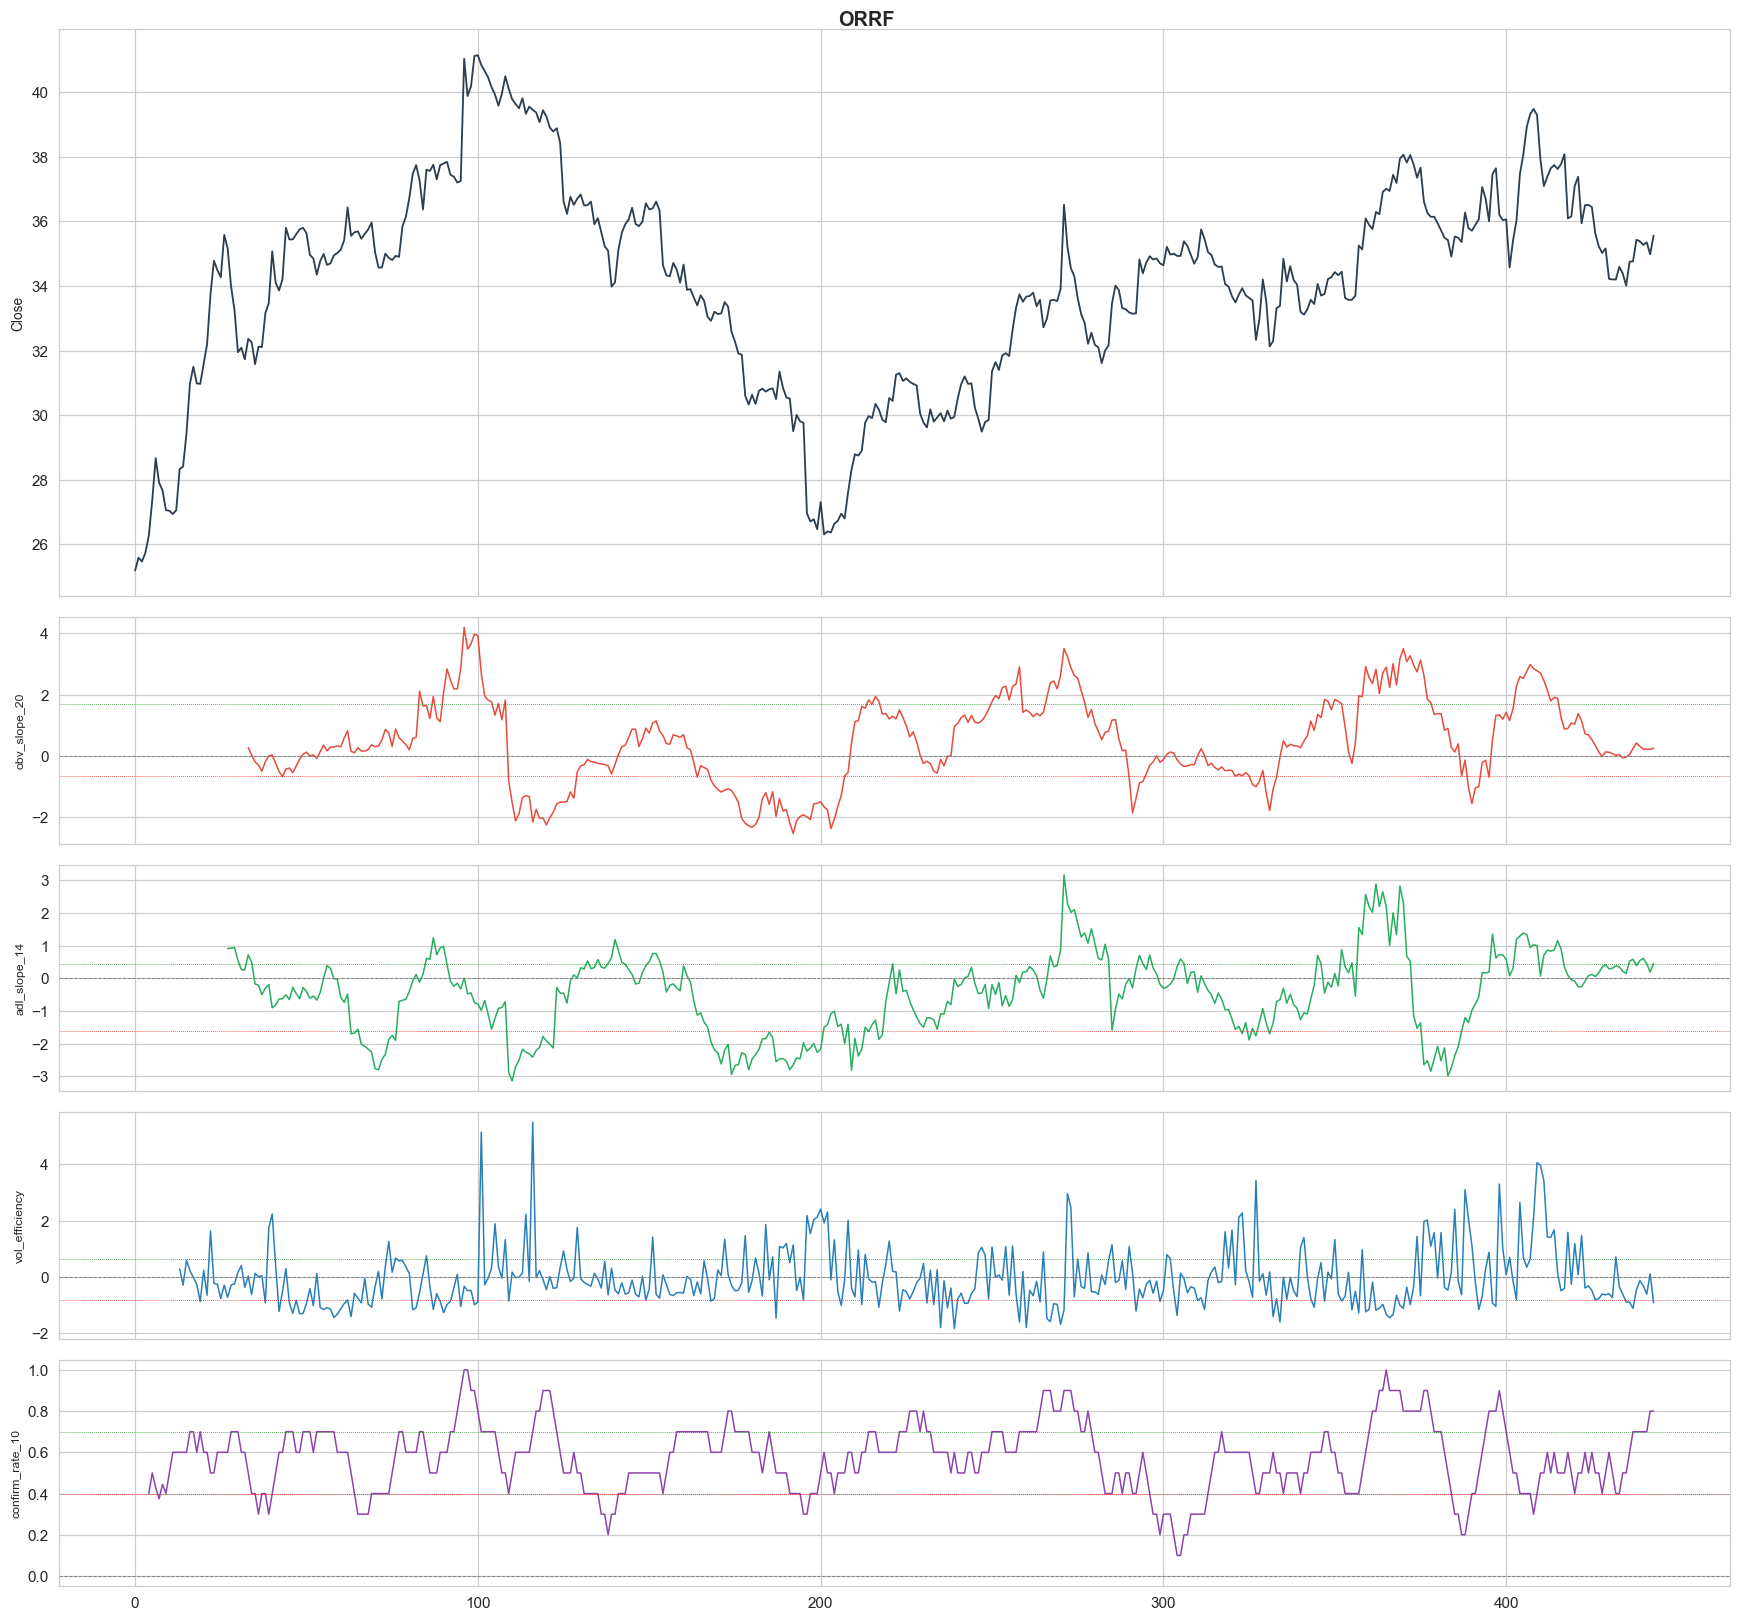

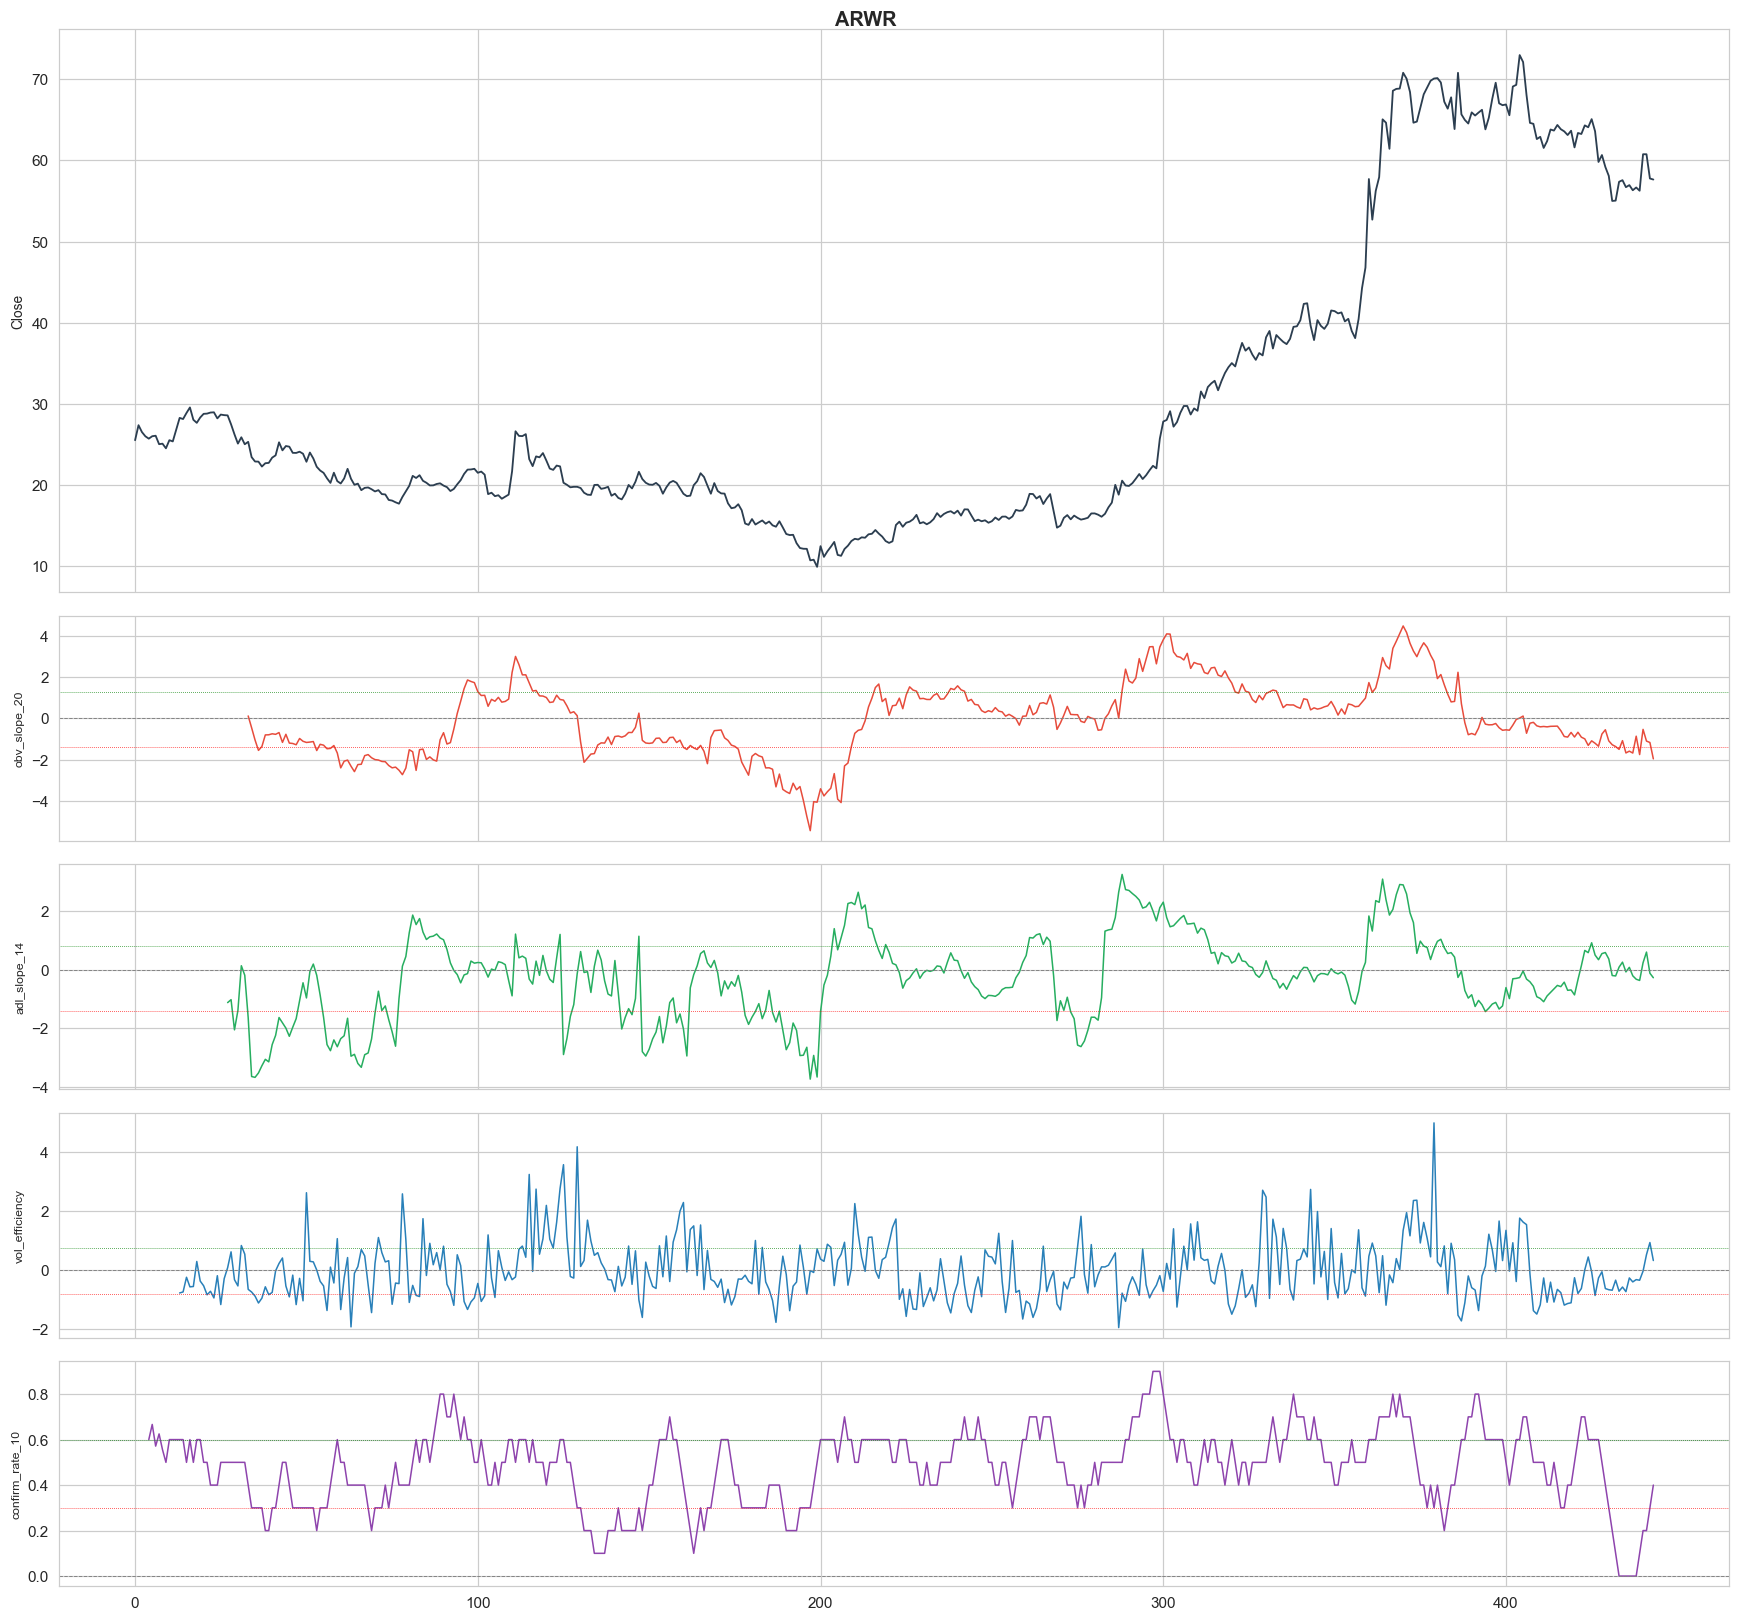

In [6]:
struct = ['acc_obv_slope_20', 'acc_adl_slope_14', 'acc_vol_efficiency', 'acc_confirm_rate_10']
for t in vis[:2]:
    plot_acc(t, ticker_dfs[t].reset_index(drop=True), struct)


## 4. Quintile Win-Rate


In [7]:
def qwin(data, feat, n=5):
    c = data[[feat, 'next_up']].dropna()
    c = c[~np.isinf(c[feat])]
    if len(c) < 200: return None
    try:
        c = c.copy()
        c['q'] = pd.qcut(c[feat], q=n, labels=False, duplicates='drop')
    except Exception: return None
    r = c.groupby('q')['next_up'].agg(['mean', 'count']).reset_index()
    r.columns = ['quintile', 'win_rate', 'count']
    return r

qwr = {f: qwin(combined, f) for f in ACC_FEATURES if f in combined.columns}
qwr = {k: v for k, v in qwr.items() if v is not None}
print(f'{len(qwr)} features OK')


10 features OK


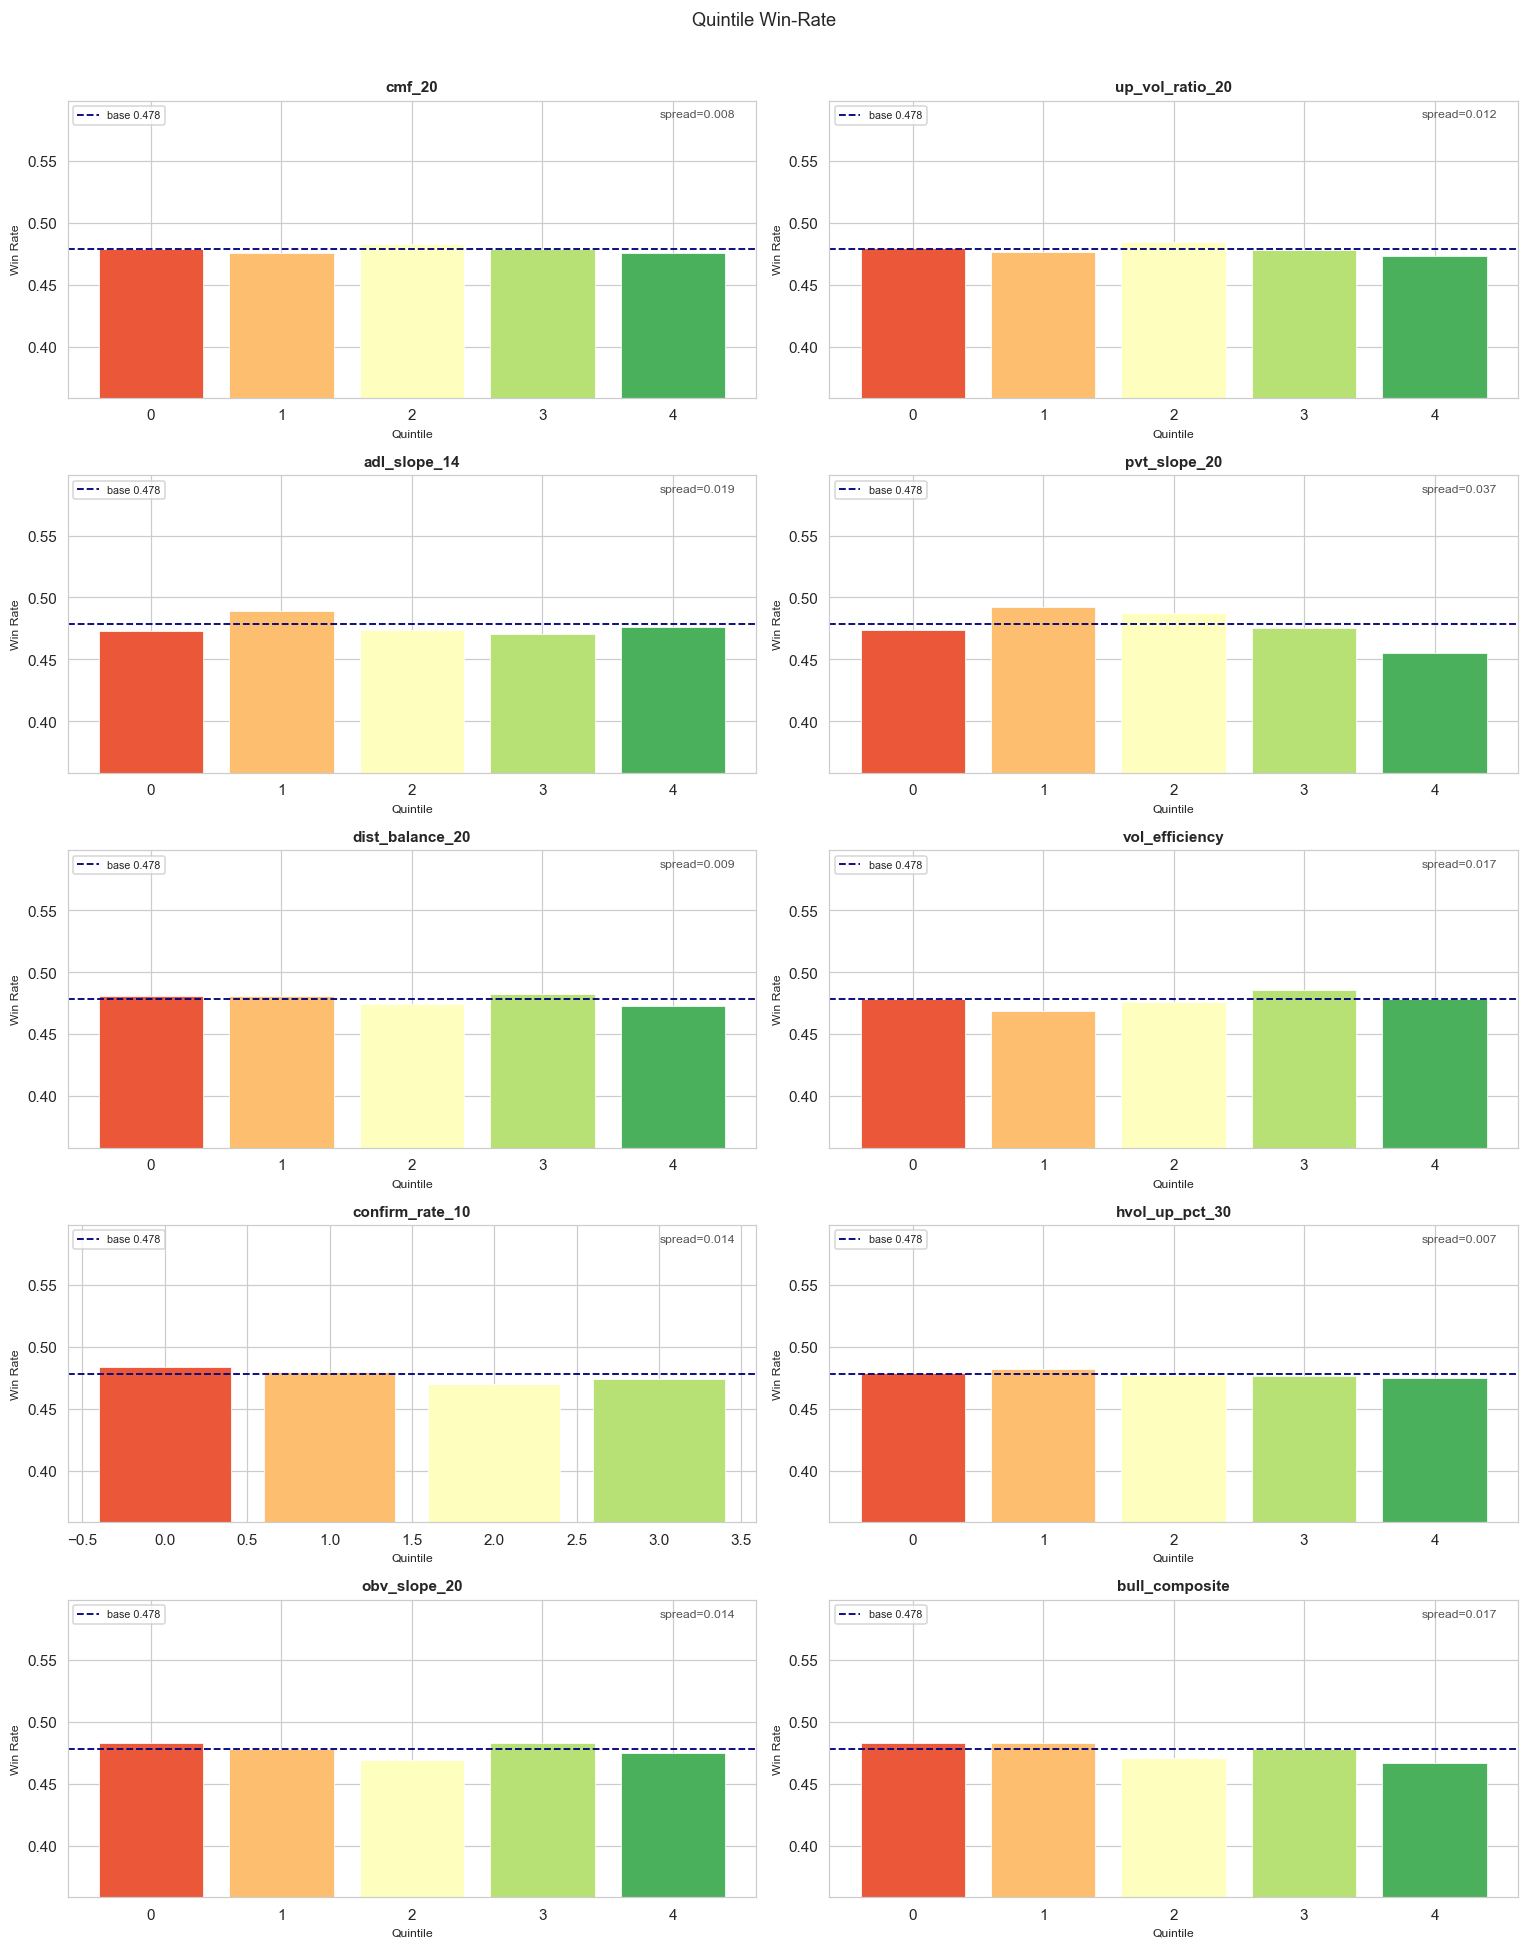

In [8]:
n_f = len(qwr); n_col = 2; n_row = int(np.ceil(n_f / n_col))
fig, axes = plt.subplots(n_row, n_col, figsize=(14, n_row*3.5))
axes = axes.flatten()
base = combined['next_up'].mean()
pal = sns.color_palette('RdYlGn', 5)
for ax, (feat, r) in zip(axes, qwr.items()):
    ax.bar(r['quintile'], r['win_rate'], color=pal, edgecolor='white', lw=0.5)
    ax.axhline(base, color='navy', lw=1.2, ls='--', label=f'base {base:.3f}')
    ax.set_title(feat.replace('acc_', ''), fontsize=10, fontweight='bold')
    ax.set_xlabel('Quintile', fontsize=8); ax.set_ylabel('Win Rate', fontsize=8)
    ax.set_ylim(max(0, base-0.12), min(1, base+0.12)); ax.legend(fontsize=7)
    spread = r['win_rate'].max() - r['win_rate'].min()
    ax.text(0.97, 0.97, f'spread={spread:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='#555')
for ax in axes[n_f:]: ax.set_visible(False)
plt.suptitle('Quintile Win-Rate', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## 5. Summary Table


In [9]:
rows = []; yb = combined['next_up'].values; yr = combined['next_return'].values
for feat in ACC_FEATURES:
    if feat not in combined.columns: continue
    x = combined[feat].values
    mask = ~(np.isnan(x)|np.isinf(x)|np.isnan(yb)|np.isnan(yr))
    if mask.sum() < 500: continue
    xc, ybc, yrc = x[mask], yb[mask], yr[mask]
    try: auc = roc_auc_score(ybc, xc)
    except: auc = 0.5
    try: rho, _ = spearmanr(xc, yrc)
    except: rho = 0.0
    q = qwr.get(feat)
    spread = q['win_rate'].max() - q['win_rate'].min() if q is not None else float('nan')
    rows.append({
        'feature': feat.replace('acc_', ''), 'auc': round(auc, 4),
        'auc_dist': round(abs(auc-0.5), 4), 'dir': '+' if auc >= 0.5 else '-',
        'spearman': round(rho, 4),
        'q_spread': round(spread, 4) if spread == spread else None,
        'n': int(mask.sum()),
    })
summary = pd.DataFrame(rows).sort_values('auc_dist', ascending=False)
summary


,feature,auc,auc_dist,dir,spearman,q_spread,n
3,pvt_slope_20,0.4912,0.0088,-,-0.0186,0.0367,61674
9,bull_composite,0.4926,0.0074,-,-0.0154,0.0169,57024
6,confirm_rate_10,0.4943,0.0057,-,-0.0104,0.0139,64224
8,obv_slope_20,0.4972,0.0028,-,-0.0075,0.0142,59874
2,adl_slope_14,0.4975,0.0025,-,-0.0072,0.0190,60774
7,hvol_up_pct_30,0.4975,0.0025,-,-0.0008,0.0073,63474
5,vol_efficiency,0.5023,0.0023,+,0.0030,0.0168,62874
4,dist_balance_20,0.4977,0.0023,-,-0.0028,0.0095,64224
1,up_vol_ratio_20,0.4978,0.0022,-,-0.0088,0.0115,63474
0,cmf_20,0.4989,0.0011,-,-0.0049,0.0076,63474


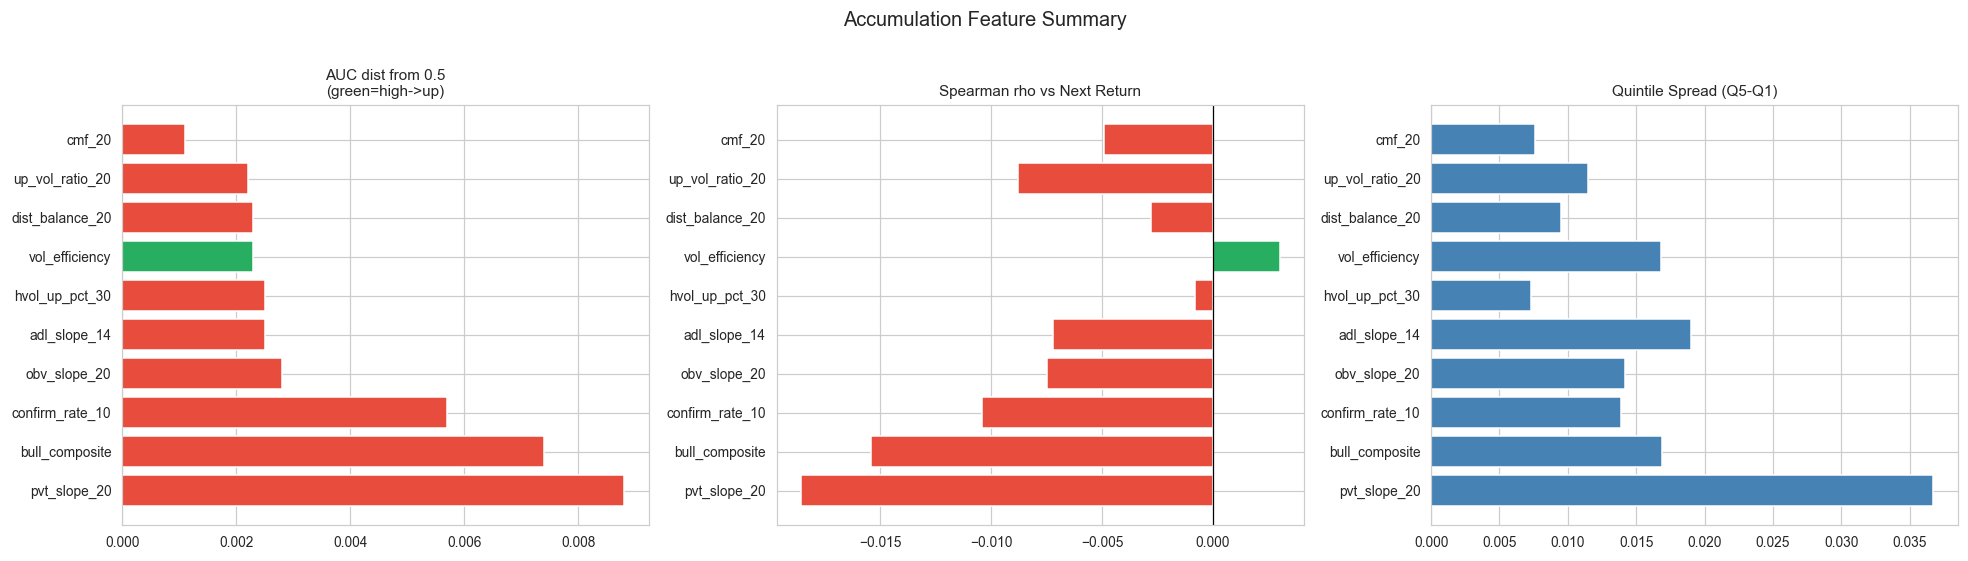

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#27ae60' if d == '+' else '#e74c3c' for d in summary['dir']]
axes[0].barh(summary['feature'], summary['auc_dist'], color=colors)
axes[0].set_title('AUC dist from 0.5\n(green=high->up)', fontsize=10)
axes[0].axvline(0, color='k', lw=0.5)
axes[1].barh(summary['feature'], summary['spearman'],
             color=['#27ae60' if r >= 0 else '#e74c3c' for r in summary['spearman']])
axes[1].set_title('Spearman rho vs Next Return', fontsize=10)
axes[1].axvline(0, color='k', lw=0.8)
axes[2].barh(summary['feature'], [v or 0 for v in summary['q_spread']], color='steelblue')
axes[2].set_title('Quintile Spread (Q5-Q1)', fontsize=10)
for ax in axes: ax.tick_params(labelsize=9)
plt.suptitle('Accumulation Feature Summary', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## 6. Correlation


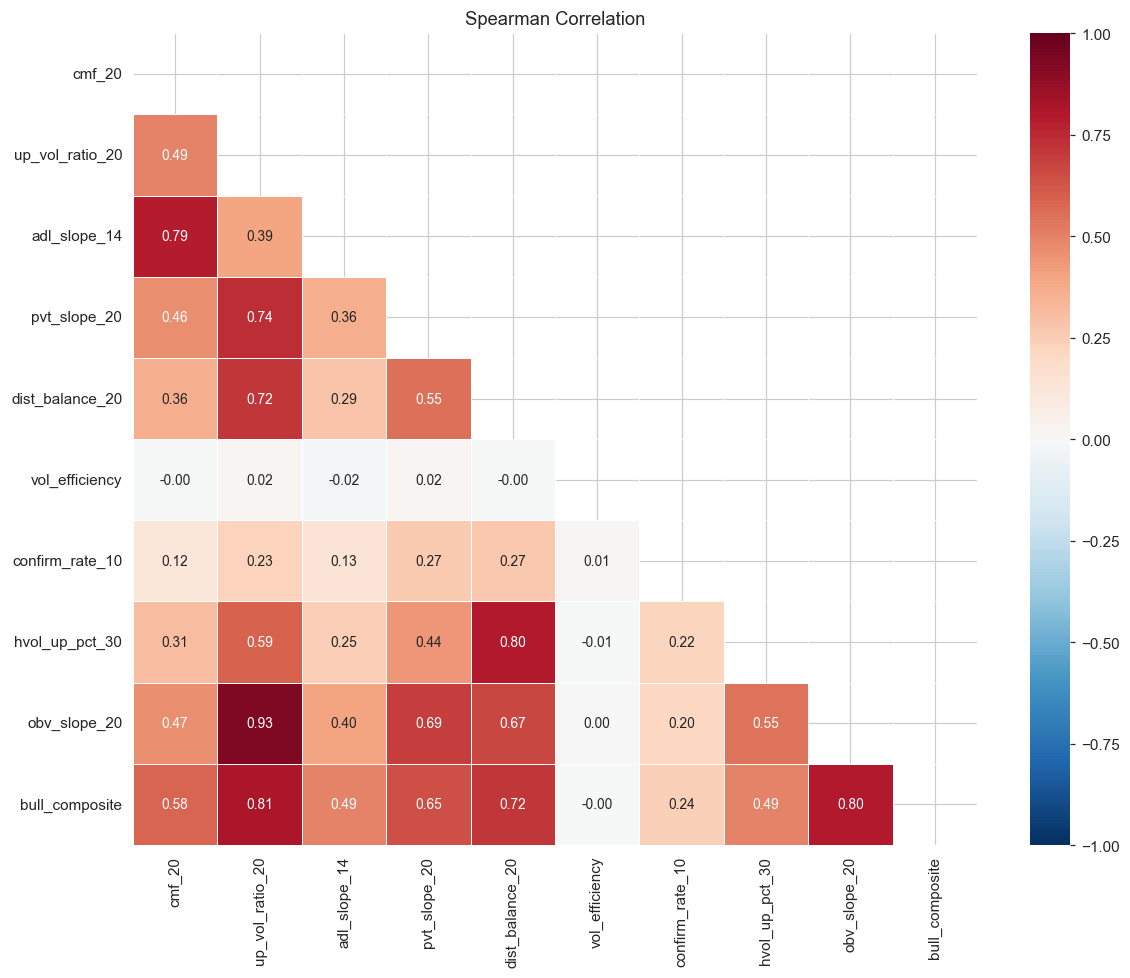

Pairs |rho|>0.7:
  adl_slope_14 <-> cmf_20  rho=0.788
  pvt_slope_20 <-> up_vol_ratio_20  rho=0.740
  dist_balance_20 <-> up_vol_ratio_20  rho=0.717
  hvol_up_pct_30 <-> dist_balance_20  rho=0.796
  obv_slope_20 <-> up_vol_ratio_20  rho=0.934
  bull_composite <-> up_vol_ratio_20  rho=0.813
  bull_composite <-> dist_balance_20  rho=0.716
  bull_composite <-> obv_slope_20  rho=0.796


In [11]:
fp = [f for f in ACC_FEATURES if f in combined.columns]
corr = combined[fp].corr(method='spearman').rename(
    index={f: f.replace('acc_', '') for f in fp},
    columns={f: f.replace('acc_', '') for f in fp})
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot_kws={'size': 9}, linewidths=0.4, ax=ax)
ax.set_title('Spearman Correlation', fontsize=12)
plt.tight_layout(); plt.show()
print('Pairs |rho|>0.7:')
found = False
for i in range(len(corr)):
    for j in range(i):
        if abs(corr.iloc[i,j]) > 0.7:
            print(f'  {corr.index[i]} <-> {corr.columns[j]}  rho={corr.iloc[i,j]:.3f}')
            found = True
if not found: print('  None.')


## 7. VIX Regime


regime           high_vix  low_vix   delta
feature                                   
bull_composite     0.0101   0.0019  0.0082
pvt_slope_20       0.0103   0.0045  0.0058
vol_efficiency     0.0056   0.0026  0.0030
obv_slope_20       0.0061   0.0034  0.0026
adl_slope_14       0.0081   0.0058  0.0024
up_vol_ratio_20    0.0045   0.0023  0.0022
confirm_rate_10    0.0060   0.0048  0.0012
cmf_20             0.0070   0.0061  0.0009
dist_balance_20    0.0015   0.0011  0.0004
hvol_up_pct_30     0.0016   0.0015  0.0001


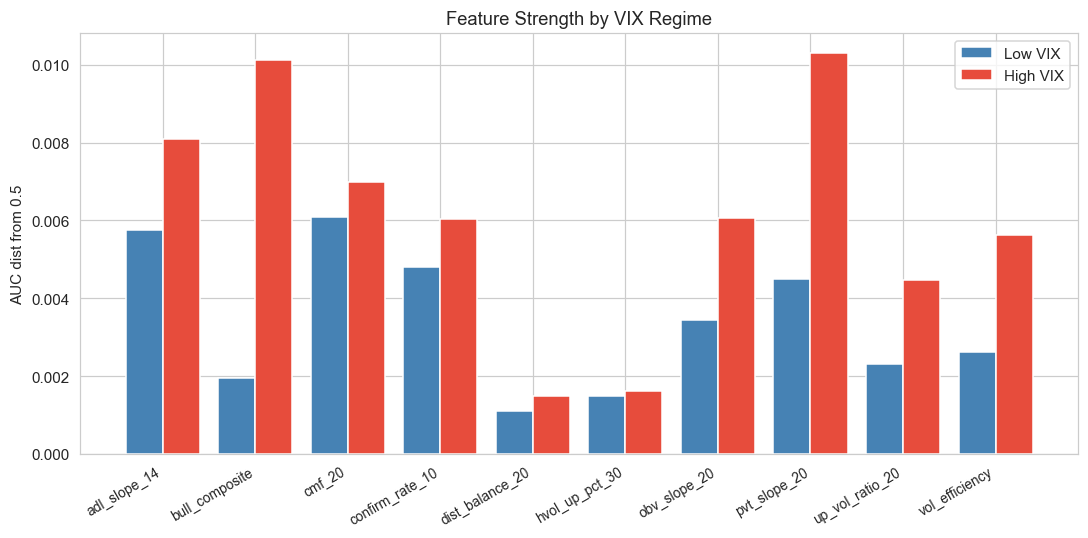

In [12]:
if 'VIX_Close' in combined.columns:
    vix_med = combined['VIX_Close'].median()
    lo = combined[combined['VIX_Close'] <= vix_med]
    hi = combined[combined['VIX_Close'] > vix_med]
    reg = []
    for regime, sub in [('low_vix', lo), ('high_vix', hi)]:
        yb2 = sub['next_up'].values
        for feat in fp:
            x2 = sub[feat].values
            m = ~(np.isnan(x2)|np.isinf(x2)|np.isnan(yb2))
            if m.sum() < 200: continue
            try: auc = roc_auc_score(yb2[m], x2[m])
            except: auc = 0.5
            reg.append({'feature': feat.replace('acc_',''), 'regime': regime, 'auc_dist': abs(auc-0.5)})
    piv = pd.DataFrame(reg).pivot(index='feature', columns='regime', values='auc_dist').fillna(0)
    piv['delta'] = piv.get('high_vix', 0) - piv.get('low_vix', 0)
    print(piv.sort_values('delta', ascending=False).round(4).to_string())
    fig, ax = plt.subplots(figsize=(10, 5))
    xp = np.arange(len(piv))
    ax.bar(xp-0.2, piv.get('low_vix',  pd.Series([0]*len(piv))).values, 0.4, label='Low VIX',  color='steelblue')
    ax.bar(xp+0.2, piv.get('high_vix', pd.Series([0]*len(piv))).values, 0.4, label='High VIX', color='#e74c3c')
    ax.set_xticks(xp); ax.set_xticklabels(piv.index, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('AUC dist from 0.5'); ax.set_title('Feature Strength by VIX Regime'); ax.legend()
    plt.tight_layout(); plt.show()
else:
    print('VIX_Close not available.')


## Reference

| Feature | Range | High value = |
|---|---|---|
| cmf_20 | [-1,+1] | Closes near bar high on big vol |
| up_vol_ratio_20 | [0,1] | Most volume came on up days |
| adl_slope_14 | z-score | A/D Line trending up |
| pvt_slope_20 | norm | PVT rising |
| dist_balance_20 | [-1,+1] | High-vol sessions favour buyers |
| vol_efficiency | z-score | LOW=absorption, HIGH=trending |
| confirm_rate_10 | [0,1] | Volume confirms price direction |
| hvol_up_pct_30 | [0,1] | Heavy sessions mostly bullish |
| obv_slope_20 | z-score | OBV accelerating up |
| bull_composite | [0,1] | All 4 core signals bullish |

**Next:** add winners to `3__AlphaSensitivity.py` inside `calculate_price_volume_indicators`.
